# **Phần 1 - Bài toán Hồi quy (Regression)**
## **1. Import thư viện & hàm**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import read_data, drop_unnecessary_columns, filter_and_clean_order_status, initialize_target_variable,handle_duplicates
from utils import optimize_logistics_timestamps, fill_product_specs_smart, handle_category_missing, standardize_column_formats

from utils import compare_outlier_methods,summarize_outliers


## **2. Định nghĩa đường dẫn**

In [2]:
# Đường dẫn tương đối của file dữ liệu
path = "../../data/"
# Kiểm tra đường dẫn có tồn tại không 
if not os.path.exists(path):
    print(f"Đường dẫn {path} không tồn tại.")
else:
    print(f"Đường dẫn {path} tồn tại.")

Đường dẫn ../../data/ tồn tại.


## **3. Mô tả dữ liệu** 
### **a. Orders Data**

Bảng này chứa thông tin về các đơn hàng được khách hàng đặt trên các nền tảng thương mại điện tử. Mỗi dòng đại diện cho một đơn hàng riêng biệt của khách hàng 
<div align="center">

| Feature                          | Mô tả                                                                 |
|----------------------------------|----------------------------------------------------------------------|
| order_id                         | Mã định danh duy nhất cho mỗi đơn hàng                              |
| customer_id                      | Mã định danh duy nhất của khách hàng đặt đơn                        |
| order_status                     | Trạng thái hiện tại của đơn hàng (ví dụ: đã giao, đang giao, đã hủy)|
| order_purchase_timestamp         | Thời điểm khách hàng đặt đơn hàng                                   |
| order_approved_at                | Thời điểm đơn hàng được xác nhận                                    |
| order_delivered_carrier_date     | Thời điểm đơn hàng được bàn giao cho đơn vị vận chuyển              |
| order_delivered_customer_date    | Thời điểm đơn hàng được giao đến khách hàng                         |
| order_estimated_delivery_date    | Ngày dự kiến giao hàng                                              |
</div>

In [3]:
orders_df = read_data(path, "olist_orders_dataset.csv")
print('Orders Data Shape: ',orders_df.shape)
display(orders_df.head())
print("Orders Data Info:")
display(orders_df.info())

Đang đọc dữ liệu từ olist_orders_dataset.csv...
Orders Data Shape:  (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Orders Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


None

### **b. Orders items**

Bảng này chứa thông tin về các mặt hàng được đặt mua trong hệ thống thương mại điện tử. Mỗi hàng đại diện cho một mặt hàng trong một đơn đặt hàng.
<div align='center'>

| Feature              | Mô tả                                                                 |
|---------------------|----------------------------------------------------------------------|
| order_id            | Mã định danh duy nhất của đơn hàng                                   |
| order_item_id       | Số thứ tự của từng sản phẩm trong cùng một đơn hàng                  |
| product_id          | Mã định danh duy nhất của sản phẩm                                   |
| seller_id           | Mã định danh duy nhất của người bán sản phẩm                         |
| shipping_limit_date | Hạn chót để sản phẩm được gửi đi                                    |
| price               | Giá của sản phẩm                                                     |
| freight_value       | Chi phí vận chuyển của sản phẩm                                     |

</div>

In [4]:
order_items_df = read_data(path, "olist_order_items_dataset.csv")
print("Orders items Data Shape: ", order_items_df.shape)
display(order_items_df.head())
print("Orders items Data Info:")
display(order_items_df.info())  

Đang đọc dữ liệu từ olist_order_items_dataset.csv...
Orders items Data Shape:  (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Orders items Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


None

### **c. Customers** 

Bảng này chứa thông tin về khách hàng. Mỗi hàng trong bảng đại diện cho một khách hàng, mỗi khách hàng được xác định bằng các thuộc tính hoặc đặc điểm được thể hiện bởi các cột trong bảng.
<div align='center'>

| Feature                    | Mô tả                                                                 |
|---------------------------|----------------------------------------------------------------------|
| customer_id               | Mã định danh duy nhất cho mỗi lần giao dịch hoặc tương tác của khách hàng |
| customer_unique_id        | Mã định danh duy nhất cho mỗi khách hàng                             |
| customer_zip_code_prefix  | Tiền tố mã bưu điện của địa chỉ khách hàng                          |
| customer_city             | Thành phố của khách hàng                                             |
| customer_state            | Bang (khu vực) của khách hàng                                        |

</div>

In [5]:
customers_df = read_data(path, "olist_customers_dataset.csv")   
print("Customers Data Shape: ", customers_df.shape)
display(customers_df.head())
print("Customers Data Info:")
display(customers_df.info())  

Đang đọc dữ liệu từ olist_customers_dataset.csv...
Customers Data Shape:  (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Customers Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


None

### **d. Sellers**

Bảng này cung cấp thông tin về người bán đã đăng ký ở trên nền tảng bán hàng. Mỗi dòng mô tả chi tiết về một người bán 
<div align='center'>

| Feature                 | Mô tả                                                           |
|------------------------|-----------------------------------------------------------------|
| seller_id              | Mã định danh duy nhất cho mỗi người bán                         |
| seller_zip_code_prefix | Tiền tố mã bưu điện của địa chỉ người bán                      |
| seller_city            | Thành phố nơi người bán hoạt động                               |
| seller_state           | Bang (khu vực) nơi người bán hoạt động                          |

</div>

In [6]:
sellers_df = read_data(path, "olist_sellers_dataset.csv")
print("Sellers Data Shape: ", sellers_df.shape)
display(sellers_df.head())
print("Sellers Data Info:")
display(sellers_df.info())


Đang đọc dữ liệu từ olist_sellers_dataset.csv...
Sellers Data Shape:  (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Sellers Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


None

### **e. Products**

Bảng này chứa tập hợp dữ liệu sản phẩm từ các nền tảng thương mại điện tử, bao gồm thông tin về nhiều sản phẩm khác nhau như mô tả sản phẩm hoặc kích thước.
<div align='center'>

| Feature                        | Mô tả                                                                 |
|--------------------------------|----------------------------------------------------------------------|
| product_id                     | Mã định danh duy nhất của sản phẩm                                   |
| product_category_name          | Danh mục mà sản phẩm thuộc về                                        |
| product_name_lenght            | Độ dài tên sản phẩm (số ký tự)                                       |
| product_description_lenght     | Độ dài mô tả sản phẩm (số ký tự)                                     |
| product_photos_qty             | Số lượng hình ảnh của sản phẩm                                       |
| product_weight_g               | Trọng lượng sản phẩm (tính bằng gram)                               |
| product_length_cm              | Chiều dài sản phẩm (cm)                                              |
| product_height_cm              | Chiều cao sản phẩm (cm)                                              |
| product_width_cm               | Chiều rộng sản phẩm (cm)                                             |

</div>

In [7]:
products_df = read_data(path, "olist_products_dataset.csv")
print("Products Data Shape: ", products_df.shape)
display(products_df.head())
print("Products Data Info:")
display(products_df.info())

Đang đọc dữ liệu từ olist_products_dataset.csv...
Products Data Shape:  (32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Products Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


None

### **f. Translation** 

Bảng này chứa tập dữ liệu dịch tên danh mục sản phẩm, được sử dụng để dịch tên danh mục sản phẩm từ tiếng Bồ Đào Nha sang tiếng Anh.
<div align='center'>

| Feature                         | Mô tả                                                      |
|---------------------------------|-----------------------------------------------------------|
| product_category_name           | Tên danh mục sản phẩm gốc bằng tiếng Bồ Đào Nha           |
| product_category_name_english   | Tên danh mục sản phẩm đã được dịch sang tiếng Anh         |

</div>

In [8]:
category_translation_df = read_data(path, "product_category_name_translation.csv")
print("Translation Data Shape: ", category_translation_df.shape)
display(category_translation_df.head())
print("Translation Data Info:")
display(category_translation_df.info())


Đang đọc dữ liệu từ product_category_name_translation.csv...
Translation Data Shape:  (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Translation Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


None

### **g. Geolocation** 
Bảng này chứa dữ liệu xác định vị trí địa lý trong thế giới thực hoặc vị trí vật lý của các đối tượng khác nhau thông qua tọa độ GPS. Mỗi hàng đại diện cho một vị trí địa lý duy nhất.

<div align='center'>

| Feature                       | Mô tả                                                                 |
|-------------------------------|----------------------------------------------------------------------|
| geolocation_zip_code_prefix   | Tiền tố mã bưu điện (CEP) của Brazil cho một khu vực cụ thể          |
| geolocation_lat              | Tọa độ vĩ độ của vị trí                                             |
| geolocation_lng              | Tọa độ kinh độ của vị trí                                           |
| geolocation_city             | Tên thành phố tương ứng với vị trí địa lý                           |
| geolocation_state            | Tên bang (khu vực) tương ứng với vị trí địa lý                      |

</div>

In [9]:
geolocation_df = read_data(path, "olist_geolocation_dataset.csv")
print("Geolocation Data Shape: ", geolocation_df.shape)
display(geolocation_df.head())
print("Geolocation Data Info:")
display(geolocation_df.info())

Đang đọc dữ liệu từ olist_geolocation_dataset.csv...
Geolocation Data Shape:  (1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Geolocation Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


None

## **4. Gộp và loại bỏ những cột dữ liệu không cần thiết**
- Gộp dữ liệu

In [10]:
# Merge các DataFrame lại với nhau
df = pd.merge(orders_df, customers_df, on='customer_id', how='left')
df = df.merge(order_items_df, on='order_id', how='left')
df = df.merge(sellers_df, on='seller_id', how='left')
df = df.merge(products_df, on='product_id', how='left')
df = df.merge(category_translation_df, on='product_category_name', how='left')

print('Merge Data Shape:',df.shape)
display(df.head())

Merge Data Shape: (113425, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,SP,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,SP,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,MG,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


- Xóa các cột dữ liệu không cần thiết 

In [11]:
df_raw = drop_unnecessary_columns(df)
print('Final Data Shape:', df_raw.shape)
display(df_raw.head())

--- ĐÃ LÀM SẠCH CỘT ---
Tổng số cột ban đầu: 30
Số cột đã bị loại bỏ: 12
Số cột còn lại: 18
Final Data Shape: (113425, 18)


,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,shipping_limit_date,price,freight_value,seller_city,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,maua,SP,500.0,19.0,8.0,13.0,housewares
1,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,barreiras,BA,2018-07-30 03:24:27,118.70,22.76,belo horizonte,SP,400.0,19.0,13.0,19.0,perfumery
2,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,vianopolis,GO,2018-08-13 08:55:23,159.90,19.22,guariba,SP,420.0,24.0,19.0,21.0,auto
3,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,sao goncalo do amarante,RN,2017-11-23 19:45:59,45.00,27.20,belo horizonte,MG,450.0,30.0,10.0,20.0,pet_shop
4,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,santo andre,SP,2018-02-19 20:31:37,19.90,8.72,mogi das cruzes,SP,250.0,51.0,15.0,15.0,stationery


- Chỉ giữ lại các dòng dữ liệu giao hàng thành công và xóa bỏ cột order_status

In [12]:
df_clean = filter_and_clean_order_status(df_raw)
print('Cleaned Data Shape:', df_clean.shape)
display(df_clean.head())

--- ĐÃ LỌC ĐƠN HÀNG ---
Tổng số đơn hàng ban đầu: 113425
Số đơn hàng đã bị loại bỏ (chưa giao hoặc lỗi ngày): 3236
Số đơn hàng còn lại: 110189
Cleaned Data Shape: (110189, 17)


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,shipping_limit_date,price,freight_value,seller_city,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,maua,SP,500.0,19.0,8.0,13.0,housewares
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,barreiras,BA,2018-07-30 03:24:27,118.70,22.76,belo horizonte,SP,400.0,19.0,13.0,19.0,perfumery
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,vianopolis,GO,2018-08-13 08:55:23,159.90,19.22,guariba,SP,420.0,24.0,19.0,21.0,auto
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,sao goncalo do amarante,RN,2017-11-23 19:45:59,45.00,27.20,belo horizonte,MG,450.0,30.0,10.0,20.0,pet_shop
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,santo andre,SP,2018-02-19 20:31:37,19.90,8.72,mogi das cruzes,SP,250.0,51.0,15.0,15.0,stationery


- Tính toán biến mục tiêu và lưu dữ liệu vào file csv

In [13]:
df_final = initialize_target_variable(df_clean)
df_final.to_csv(f"{path}raw_data.csv",index =False)

--- KHỞI TẠO BIẾN MỤC TIÊU ---
- Số dòng bị loại bỏ (do thiếu ngày giao hoặc lỗi logic): 0
- Số lượng mẫu còn lại: 110189
- Thời gian giao hàng trung bình trong tập dữ liệu: 12.47 ngày


## **5. Thống kê mô tả dữ liệu sau khi gộp**

In [14]:
print(f"Kích thước của dữ liệu: {df_final.shape}")
df_final.info()

Kích thước của dữ liệu: (110189, 18)
<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 0 to 113424
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_purchase_timestamp       110189 non-null  datetime64[ns]
 1   order_approved_at              110174 non-null  object        
 2   order_delivered_carrier_date   110188 non-null  object        
 3   order_delivered_customer_date  110189 non-null  datetime64[ns]
 4   order_estimated_delivery_date  110189 non-null  object        
 5   customer_city                  110189 non-null  object        
 6   customer_state                 110189 non-null  object        
 7   shipping_limit_date            110189 non-null  object        
 8   price                          110189 non-null  float64       
 9   freight_value                  110189 non-null  float64       
 10  seller_city                    11018

In [15]:
df_final.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,110189,2018-01-02 02:39:32.673823744,2016-09-15 12:16:38,2017-09-15 04:48:38,2018-01-21 09:13:44,2018-05-05 15:38:37,2018-08-29 15:00:37,NaN
order_delivered_customer_date,110189,2018-01-14 13:59:34.689261056,2016-10-11 13:46:32,2017-09-26 20:15:35,2018-02-02 21:05:09,2018-05-15 20:14:33,2018-10-17 13:22:46,NaN
price,110189.0,119.977937,0.85,39.9,74.9,134.17,6735.0,182.304615
freight_value,110189.0,19.948869,0.0,13.08,16.26,21.15,409.68,15.698615
product_weight_g,110171.0,2089.687813,0.0,300.0,700.0,1800.0,40425.0,3741.682542
product_length_cm,110171.0,30.142551,7.0,18.0,25.0,38.0,105.0,16.122279
product_height_cm,110171.0,16.555427,2.0,8.0,13.0,20.0,105.0,13.409562
product_width_cm,110171.0,22.986258,6.0,15.0,20.0,30.0,118.0,11.68796
target_delivery_days,110189.0,12.472246,0.533414,6.736192,10.184201,15.54081,209.628611,9.445346


## **6. Phân tích khám phá (EDA)**
### **a. Biểu đồ 1: Phân phối biến mục tiêu**

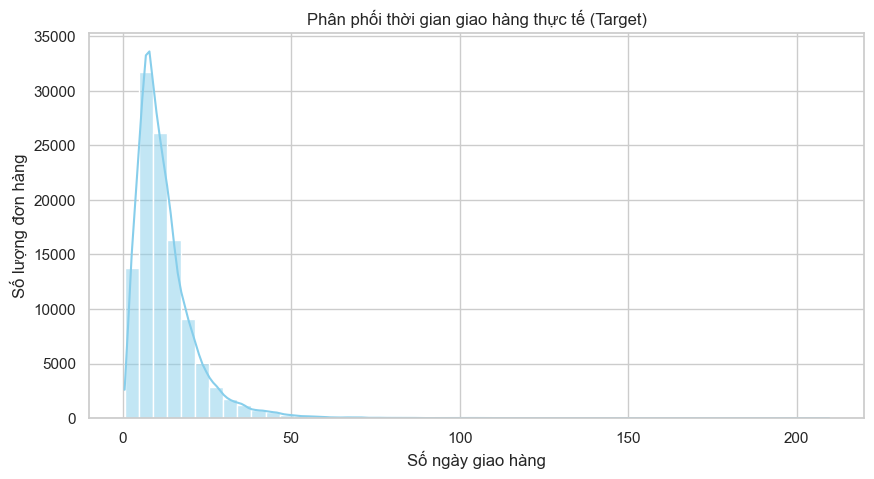

In [16]:
#df_final['order_purchase_timestamp'] = pd.to_datetime(df_final['order_purchase_timestamp'])
sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df_final['target_delivery_days'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối thời gian giao hàng thực tế (Target)')
plt.xlabel('Số ngày giao hàng')
plt.ylabel('Số lượng đơn hàng')
plt.show()

#### Nhận xét: Dữ liệu lệch phải. Đa số đơn hàng giao dưới 20 ngày.

### **b. Biểu đồ 2: Ma trận tương quan**

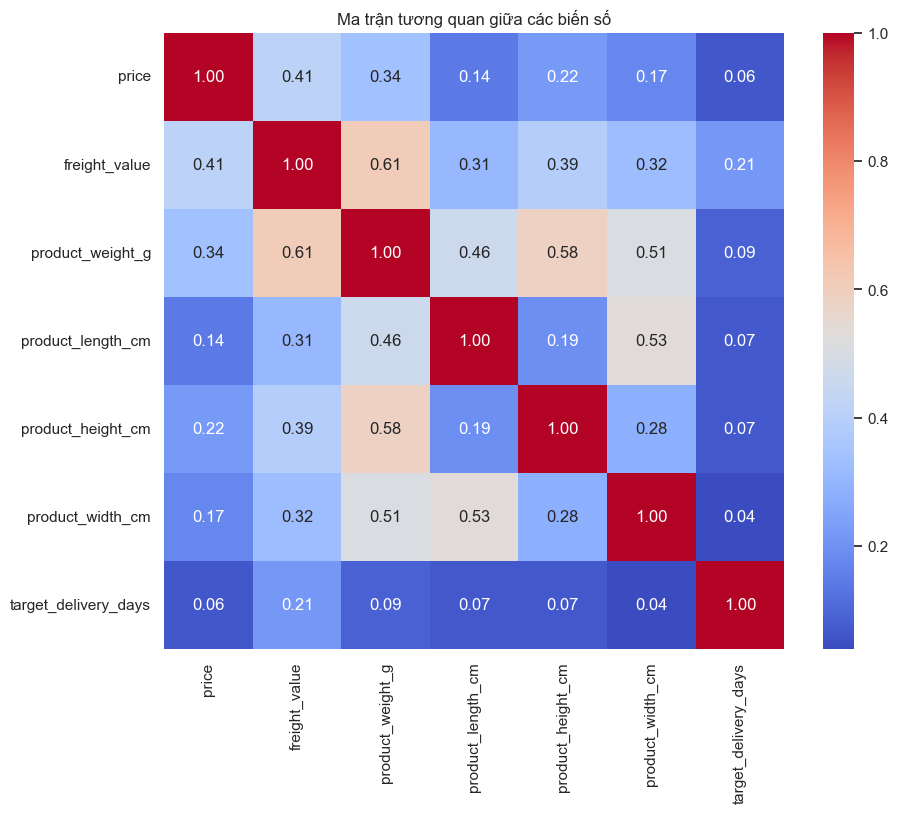

In [17]:
plt.figure(figsize=(10,8))
numerical_cols = ['price', 'freight_value', 'product_weight_g', 
                  'product_length_cm', 'product_height_cm', 
                  'product_width_cm', 'target_delivery_days']
sns.heatmap(df_final[numerical_cols].corr(), annot = True, cmap ='coolwarm', fmt ='.2f')
plt.title("Ma trận tương quan giữa các biến số")
plt.show()


#### Nhận xét:
- 'freight_value' (phí ship) và 'product_weight_g' (trọng lượng) có tương quan thuận mạnh (0.61).
- 'price' không ảnh hưởng nhiều đến thời gian giao hàng.
### **c. Biểu đồ 3: Boxplot theo Bang**

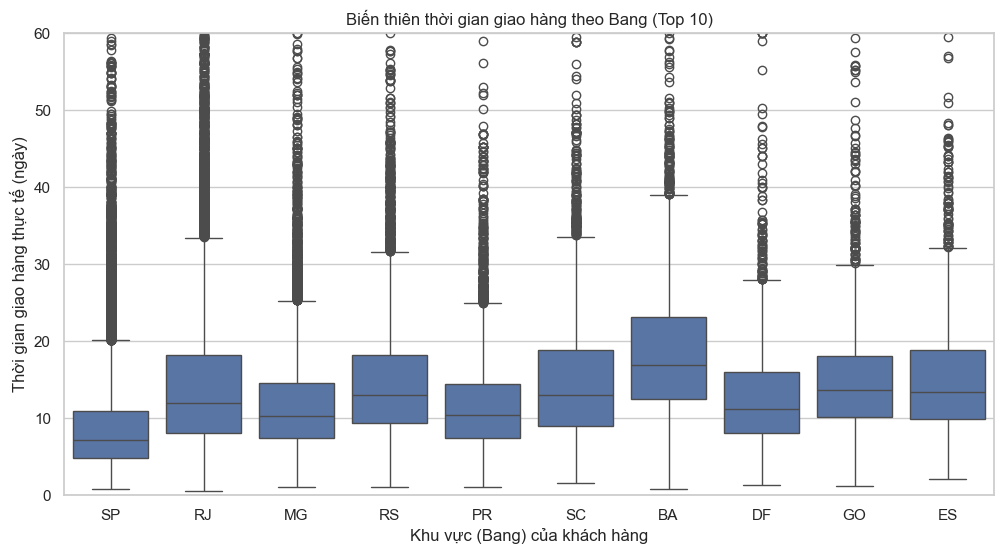

In [18]:
top_states = df_final['customer_state'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='customer_state', y='target_delivery_days', 
            data=df_final[df_final['customer_state'].isin(top_states)], order=top_states)
plt.title('Biến thiên thời gian giao hàng theo Bang (Top 10)')
plt.ylim(0, 60) # Giới hạn để thấy được phần lớn dữ liệu
plt.ylabel("Thời gian giao hàng thực tế (ngày)")
plt.xlabel("Khu vực (Bang) của khách hàng")
plt.show()

#### Nhận xét:
- Bang SP (Sao Paulo) có thời gian giao hàng nhanh và ổn định nhất.
- Các bang xa trung tâm như BA (Bahia) có thời gian giao hàng trung bình cao hơn và dải biến thiên rộng.
### **d. Biểu đồ 4: Xu hướng theo thời gian**

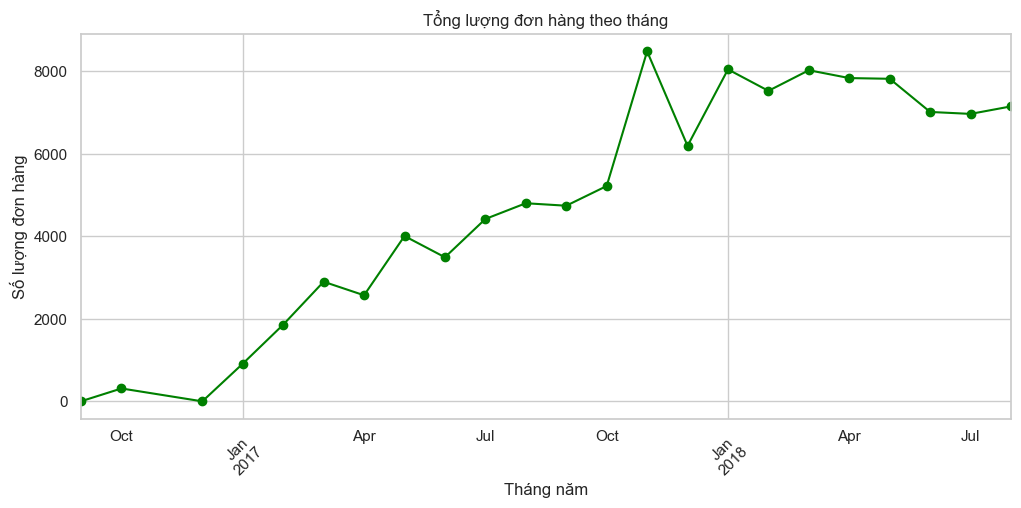

In [19]:
df_final['month_year'] = df_final['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df_final.groupby('month_year').size()
plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o', color='green')
plt.title('Tổng lượng đơn hàng theo tháng')
plt.xticks(rotation=45)
plt.ylabel("Số lượng đơn hàng")
plt.xlabel("Tháng năm")
plt.show()

#### Nhận xét: Lượng đơn hàng tăng trưởng đều theo thời gian, có đỉnh cao vào cuối năm 2017 (Black Friday).
#### **e. Biểu đồ 5: Top danh mục sản phẩm**

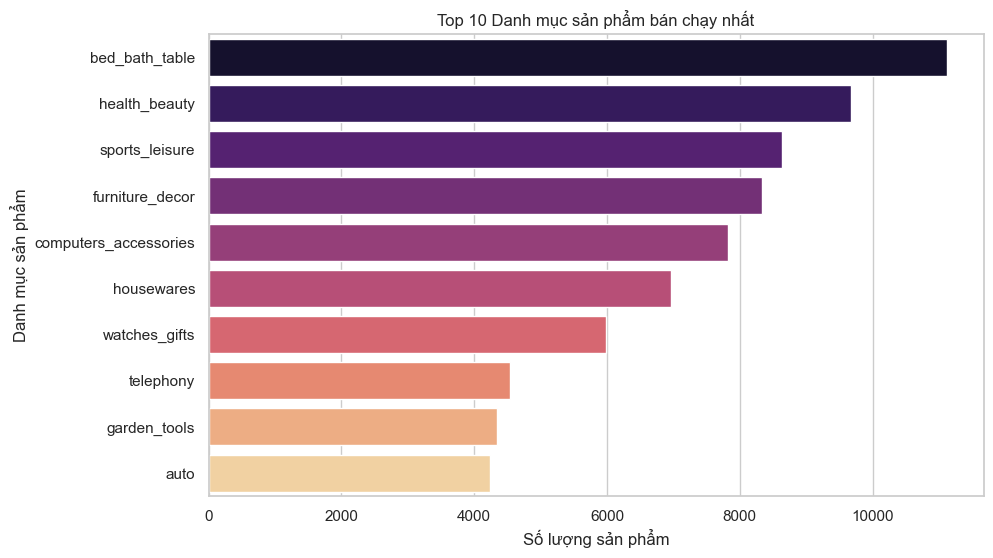

In [20]:
top_cats = df['product_category_name_english'].value_counts().nlargest(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_cats.values, 
    y=top_cats.index, 
    hue=top_cats.index, 
    palette='magma', 
    legend=False
)
plt.title('Top 10 Danh mục sản phẩm bán chạy nhất')
plt.ylabel('Danh mục sản phẩm')
plt.xlabel('Số lượng sản phẩm')
plt.show()

## **7. Tiền xử lý dữ liệu**
### **a. Xử lý missing values**

In [21]:
print("Thống kê số lượng giá trị còn thiếu ở mỗi cột:")
print(df_final.isnull().sum())

Thống kê số lượng giá trị còn thiếu ở mỗi cột:
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date        1
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_city                       0
customer_state                      0
shipping_limit_date                 0
price                               0
freight_value                       0
seller_city                         0
seller_state                        0
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_category_name_english    1559
target_delivery_days                0
month_year                          0
dtype: int64


- Xử lý giá trị thiếu ở 2 cột order_approved_at và order_delivered_carrier_date

In [22]:
df_final = optimize_logistics_timestamps(df_final)

--- Xử lý cột: order_approved_at ---
   + Số dòng đã điền: 15
   + Khoảng lệch trung vị (Median): 0.35 giờ
------------------------------
--- Xử lý cột: order_delivered_carrier_date ---
   + Số dòng đã điền: 1
   + Khoảng lệch trung vị (Median): 44.06 giờ
------------------------------


- Xử lý giá trị thiếu ở các cột kích thước sản phẩm

In [23]:
df_final = fill_product_specs_smart(df_final)

--- XỬ LÝ KÍCH THƯỚC & TRỌNG LƯỢNG ---
-> Cột product_weight_g: Đã điền 18 dòng. (Global Median dùng: 700.0)
-> Cột product_length_cm: Đã điền 18 dòng. (Global Median dùng: 25.0)
-> Cột product_height_cm: Đã điền 18 dòng. (Global Median dùng: 13.0)
-> Cột product_width_cm: Đã điền 18 dòng. (Global Median dùng: 20.0)


- Xử lý giá trị thiếu ở cột phân loại sản phẩm

In [24]:
df_final = handle_category_missing(df_final)

--- XỬ LÝ DANH MỤC ---
-> Đã điền 1559 dòng trống bằng nhãn 'other'.


### **b. Chuẩn hóa định dạng dữ liệu**

In [25]:
df_final = standardize_column_formats(df_final)

--- CHUẨN HÓA ĐỊNH DẠNG HOÀN TẤT ---


In [26]:
print(df_final.columns)

Index(['order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_city', 'customer_state',
       'shipping_limit_date', 'price', 'freight_value', 'seller_city',
       'seller_state', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'target_delivery_days', 'month_year'],
      dtype='object')


In [29]:
cols = ['price', 'freight_value', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'target_delivery_days']

df_processed = compare_outlier_methods(df_final, cols)
summarize_outliers(df_processed)


---Tổng kết xử lí Outliers---
Tổng số bản ghi: 99970
Số bản ghi IQR: 25046
Số bản ghi Isolation Forest: 4999
Số bản ghi cả 2: 4999
Số lượng IQR xóa nhưng Isolation Forest giữ lại là 20047


### **c. Chuẩn hóa dữ liệu**

### **d. Xử lý duplicate**

In [28]:
df_final =handle_duplicates(df_final)

--- XỬ LÝ TRÙNG LẶP HOÀN TẤT ---
- Số lượng dòng trùng lặp đã xóa: 10,219
- Kích thước dữ liệu sau khi xóa: (99970, 19)
------------------------------
